<a href="https://colab.research.google.com/github/EvM82/Classical-Machine-Learning-for-Classifi--cation/blob/main/Dimension_Reduction_and_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist
from scipy.stats import mode

## CIFAR-10

In [ ]:
from tensorflow.keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
x_train: (50000, 32, 32, 3) y_train: (50000, 1)
x_test : (10000, 32, 32, 3) y_test : (10000, 1)


In [ ]:
# Flatten: 32x32x3 -> 3072 features
x_train = x_train.reshape(len(x_train), -1).astype('float32')
x_test  = x_test.reshape(len(x_test),  -1).astype('float32')

# Normalization of data
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled  = scaler.transform(x_test)


# Ensure that labels are 1D
y_train = y_train.ravel()
y_test  = y_test.ravel()

print("x_train:", x_train_scaled.shape, "y_train:", y_train.shape)
print("x_test :", x_test_scaled.shape,  "y_test :", y_test.shape)

x_train: (50000, 3072) y_train: (50000,)
x_test : (10000, 3072) y_test : (10000,)


In [ ]:
n_train = 20000
n_test  = 10000

x_train_scaled = x_train_scaled[:n_train]
y_train = y_train[:n_train]

x_test_scaled = x_test_scaled[:n_test]
y_test = y_test[:n_test]


## PC Parts

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_dir = "/content/drive/MyDrive/pc_parts"
data = []

for label in os.listdir(root_dir):
    label_path = os.path.join(root_dir, label)

    if not os.path.isdir(label_path):
        continue

    for filename in os.listdir(label_path):
        filepath = os.path.join(label_path, filename)

        if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif")):
            data.append([filepath, label])

df = pd.DataFrame(data, columns=["filepath", "label"])

print(df.head())
print("Σύνολο εικόνων:", len(df))


                                          filepath    label
0  /content/drive/MyDrive/pc_parts/headset/120.jpg  headset
1  /content/drive/MyDrive/pc_parts/headset/144.jpg  headset
2  /content/drive/MyDrive/pc_parts/headset/149.jpg  headset
3  /content/drive/MyDrive/pc_parts/headset/143.jpg  headset
4  /content/drive/MyDrive/pc_parts/headset/129.jpg  headset
Σύνολο εικόνων: 894


In [ ]:
#Function to convert images (the ones of df to 32x32)
def load_and_resize(path, size=(32, 32)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img)

X = np.stack(df["filepath"].apply(lambda p: load_and_resize(p, (32, 32))))
y = df["label"].values

print("Raw X shape:", X.shape)
print("Raw y shape:", y.shape)

# Transform labels in integer form
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Unique labels:", le.classes_)
print("y_enc shape:", y_enc.shape)

Raw X shape: (894, 32, 32, 3)
Raw y shape: (894,)
Unique labels: ['cpu' 'gpu' 'headset' 'keyboard' 'microphone']
y_enc shape: (894,)


Η παρακάτω διαδικασία εφαρμόζεται για το Spectral Embedding, καθώς η μέθοδος δεν παρέχει συνάρτηση transform και, άρα γίνεται πρώτα embeded ολόκληρο το σύνολο δεδομένων, πριν από τον διαχωρισμό σε σύνολα εκπαίδευσης και ελέγχου. Όταν δωθούν δεδομένα στην SpectralCLuster(πιο μετά) θα είναι ήδη χωρισμένα σε train-test.

In [ ]:
# Flatten: (N,32,32,3) -> (N, 3072)
x_train = X.reshape(len(X), -1).astype("float32")
print("x_train:", x_train.shape)

# Normalization of data
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)

# Ensure that labels are 1D
y_train = y_enc.ravel()


x_train: (894, 3072)


Η παρακάτω διαδικασία εφαρμόζεται για Isomap και LLE, καθώς oi μέθοδοι αυτές διαθέτουν συνάρτηση transform, επιτρέποντας embedding στο test set ξχωριστά.

In [ ]:
# Split the dataset in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y_enc,test_size=0.2,stratify=y_enc,random_state=42)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# Flatten: (N,32,32,3) -> (N, 3072)
x_train = X_train.reshape(len(X_train), -1).astype("float32")
x_test  = X_test.reshape(len(X_test),  -1).astype("float32")

print("After flatten:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

# Normalization of data
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled  = scaler.transform(x_test)

# Ensure that labels are 1D
y_train = y_train.ravel()
y_test  = y_test.ravel()


X_train: (715, 32, 32, 3) y_train: (715,)
X_test : (179, 32, 32, 3) y_test : (179,)
After flatten:
x_train: (715, 3072)
x_test : (179, 3072)


##Dimension Reduction in 2D- Spectral Embedding

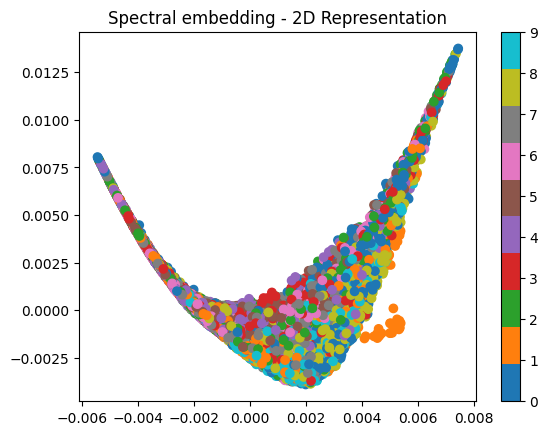

In [ ]:
se = SpectralEmbedding( n_components=2, n_neighbors=10, affinity='nearest_neighbors', random_state=42)
x_se = se.fit_transform(x_train_scaled)

# Plot the embedded data
plt.scatter(x_se[:, 0], x_se[:, 1], c=y_train, cmap='tab10')
plt.title('Spectral embedding - 2D Representation')
plt.colorbar()
plt.show()

Το Spectral Embedding δεν διαθετει tansform method/function, οποτε γινεται fit σε όλο το σύνολο των train και το test θα προκύψει από εκεί με split στο 2D embedding. Spectral Clustering δεν θα δει test δεδομένα, θα αφαιρεθούν από το input embedding που θα δωθεί.

In [ ]:
x_se_train, x_se_test, y_se_train, y_se_test = train_test_split(x_se, y_train,test_size=0.2,stratify=y_train,random_state=42)
print("X_train:", x_se_train.shape, "y_train:", y_se_train.shape)
print("X_test :", x_se_test.shape,  "y_test :", y_se_test.shape)

X_train: (16000, 2) y_train: (16000,)
X_test : (4000, 2) y_test : (4000,)


## Dimension Reduction in 2D - LLE



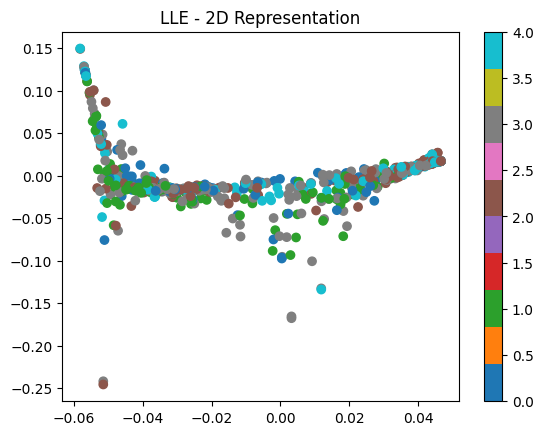

In [ ]:
lle = LocallyLinearEmbedding (n_neighbors=10, n_components=2, method='standard', random_state=42)
x_se_train = lle.fit_transform( x_train_scaled)
y_se_train=y_train

x_se_test=lle.transform(x_test_scaled)
y_se_test=y_test

plt.scatter(x_se_train[:, 0], x_se_train[:, 1], c=y_se_train, cmap='tab10')
plt.title('LLE - 2D Representation')
plt.colorbar()
plt.show()

## Dimension Reduction in 2D - Isomap



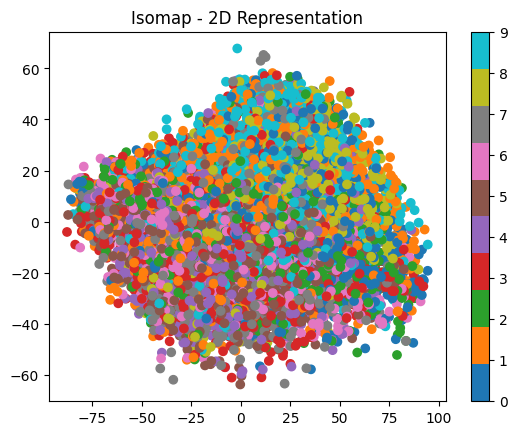

In [ ]:
isomap = Isomap(n_neighbors=10, n_components=2)
x_se_train = isomap.fit_transform(x_train_scaled)
y_se_train=y_train

x_se_test=isomap.transform(x_test_scaled)
y_se_test=y_test


plt.scatter(x_se_train[:, 0], x_se_train[:, 1], c=y_se_train, cmap='tab10')
plt.title('Isomap - 2D Representation')
plt.colorbar()
plt.show()

## Spectral Clustering

Eigengaps

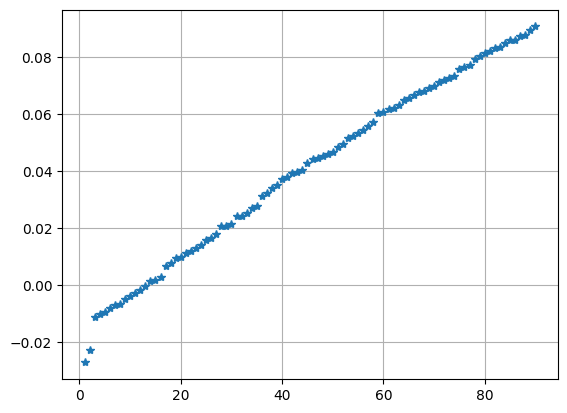

In [ ]:
n_neighbors2 = 50
W = kneighbors_graph(x_se_train, n_neighbors=n_neighbors2, mode="connectivity", include_self=False)
# normalized Laplacian
L = laplacian(W, normed=True)

m = 30
eigvals, _ = eigsh(L, k=m, which="SM")  # SM = smallest magnitude
eigvals = np.sort(eigvals)


plt.figure()
plt.plot(np.arange(1, m+1), eigvals, marker='*', linestyle='None')
plt.grid(True)
plt.show()


Clustering

In [ ]:
k_values = [2,3,4,5,6,7,8,9,10,11,12]

for k in k_values:
    sc = SpectralClustering(n_clusters=k,affinity='nearest_neighbors', n_neighbors=n_neighbors2,assign_labels='kmeans',random_state=42)
    c = sc.fit_predict(x_se_train)

    ari = adjusted_rand_score(y_se_train, c)
    nmi = normalized_mutual_info_score(y_se_train, c)

    print(f"k={k:2d}  ARI={ari:.4f}  NMI={nmi:.4f}")



k= 2  ARI=0.0300  NMI=0.0373
k= 3  ARI=0.0603  NMI=0.0775
k= 4  ARI=0.0459  NMI=0.0693
k= 5  ARI=0.0498  NMI=0.0783
k= 6  ARI=0.0533  NMI=0.0776
k= 7  ARI=0.0700  NMI=0.0911
k= 8  ARI=0.0611  NMI=0.0969
k= 9  ARI=0.0594  NMI=0.0998
k=10  ARI=0.0396  NMI=0.0947
k=11  ARI=0.0412  NMI=0.0984
k=12  ARI=0.0358  NMI=0.1014


plot for best k

Εκτελεί ξανά SpectralClustering για συγκεκριμένο k και οπτικοποιεί το αποτέλεσμα.

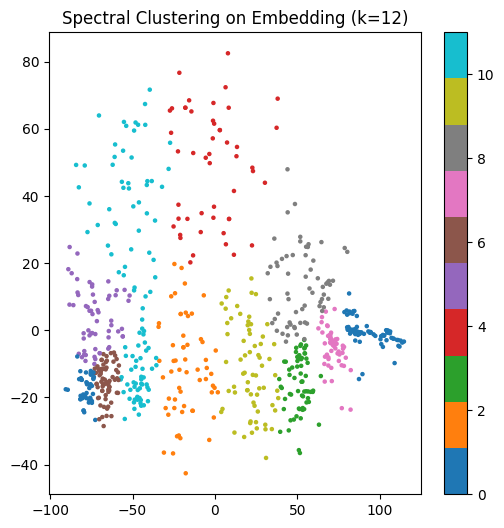

In [ ]:
k_f =12 # different in each case (lle, isomap, spectral embedding) and the n_neighboors
sc = SpectralClustering(
    n_clusters=k_f,
    affinity='nearest_neighbors',
    n_neighbors=n_neighbors2,
    assign_labels='kmeans',
    random_state=42
)
c_f = sc.fit_predict(x_se_train)

plt.figure(figsize=(6,6))
plt.scatter(x_se_train[:,0], x_se_train[:,1], c=c_f, cmap='tab10', s=5)
plt.title(f"Spectral Clustering on Embedding (k={k_f})")
plt.colorbar()
plt.show()


## Test

Βρίσκει centroids

In [ ]:
centroids = []
for i in range(k_f):
    centroids.append(x_se_train[c_f == i].mean(axis=0))

centroids = np.vstack(centroids)  # (k, 2)

TEST: βρίσκει nearest centroid



In [ ]:
# distances--> (n_test, k)
distances = cdist(x_se_test, centroids, metric='euclidean')

# nearest centroid
test_cluster_labels = distances.argmin(axis=1)

Μετατροπή clusters → classes (majority vote)

Κάθε cluster αντιστοιχίζεται στην επικρατέστερη κλάση των δειγμάτων εκπαίδευσης που περιέχει, και τα δεδομένα ελέγχου ταξινομούνται βάσει της κλάσης του πλησιέστερου cluster.

In [ ]:
cluster_to_class = {}

for i in range(k_f):
    labels_in_cluster = y_se_train[c_f == i]
    cluster_to_class[i] = mode(labels_in_cluster, keepdims=True).mode[0]

# predict test labels
y_test_pred = np.array([cluster_to_class[c_f] for c_f in test_cluster_labels])


acc

In [ ]:
acc = accuracy_score(y_se_test, y_test_pred)
print(f"Test accuracy (nearest centroid): {acc:.4f}")

Test accuracy (nearest centroid): 0.3352
